# Delta-Base Planning from Differentiable Flowsheets

Refinery and value-chain planning has been done for decades with linear programs whose unit
submodels are *base plus delta vectors* — a first-order Taylor expansion
$y \approx y_0 + J\,(u - u_0)$. Aspen PIMS, Haverly GRTMPS, Honeywell RPMS and AVEVA Spiral
Plan all work this way; the refereed anchor is Baker and Lasdon, *Successive Linear
Programming at Exxon*, Management Science **31**(3), 1985.

In all of those systems the delta vectors are built by **perturbing a rigorous simulator one
variable at a time**, which costs $O(n)$ model evaluations and is why they are refreshed on
the order of annually.

A difflow flowsheet is a pure function with its flash, recycle and unit solves embedded, so
`jax.jacobian` returns the *reduced* input–output sensitivity directly — already implicitly
differentiated through those inner solves. **That reduced Jacobian is the delta vector.** AD
builds it in $\min(n_u, n_y)$ passes — forward mode one per input, reverse mode one per
output, each a small multiple of one model evaluation — against the $2n_u$ evaluations of
central differences, and it is exact rather than truncated. Where the output is a single
number, such as the planner's objective, that is one reverse pass: the *gradient* costs
$O(1)$ evaluations however many decisions there are.

This notebook works a two-plant chain end to end:

1. the flowsheet: units, streams, and which of them the plan may move,
2. what is being planned — the objective, the decisions, the constraints,
3. the delta vectors: what they are, and what they are only locally,
4. what the derivatives cost,
5. the LP that actually gets solved, written out,
6. the trust region, and why it needs an acceptance test,
7. the plan, and an allocation lever that switches corner with prices,
8. the sensitivity of the *plan itself*,
9. the phase-boundary diagnostic,
10. whether large models lose their gradients,
11. handing the program to Pyomo,
12. where the boundary of this module is.

In [1]:
import warnings

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from tabulate import tabulate

from difflow.planning import (
    Block, Network, DeltaBasePlanner, PhaseBoundaryWarning,
    check_delta_vectors, choose_ad_mode, linearize_block, planner_objective,
    price_switch_point, scaling_study, format_scaling_table,
    draw_chain, draw_delta_vectors, draw_planning_network, draw_taylor_model,
    draw_trust_region,
)
from difflow.planning import chain as chain_mod

plt.rcParams.update({"figure.figsize": (7.0, 4.0), "figure.dpi": 110})


def table(rows, headers):
    """Render a table as Markdown, so it lands in the notebook as a table."""
    display(Markdown(tabulate(rows, headers=headers, tablefmt="github",
                              disable_numparse=True)))

## 1. The flowsheet

Two plants, coupled through the residue gas:

* **NGL recovery** — a turbo-expander sets the pressure, a real cryogenic flash
  (`difflow.units.flash.Flash`, with a Rachford–Rice root find inside it) drops out a cold
  liquid, a reflux contactor pushes heavies out of the residue gas, and a deethanizer
  decides how much ethane leaves as product rather than staying in the gas. Four decisions.
* **Gas-turbine power** — burns the residue gas with a part-load efficiency curve, and an
  allocation lever chooses between burning it and selling it. One decision.

`ngl.residue_F → power.fuel_F` is a **link**: the downstream plant's inlet is whatever the
upstream plant produces, so it is not a free decision.

The model ships as `difflow.planning.chain` so the notebook, the docs and the regression
tests all describe the same problem. Its thermodynamics are ideal and the flowsheet is
schematic — it is a faithful *shape* of a planning problem, not a plant design.

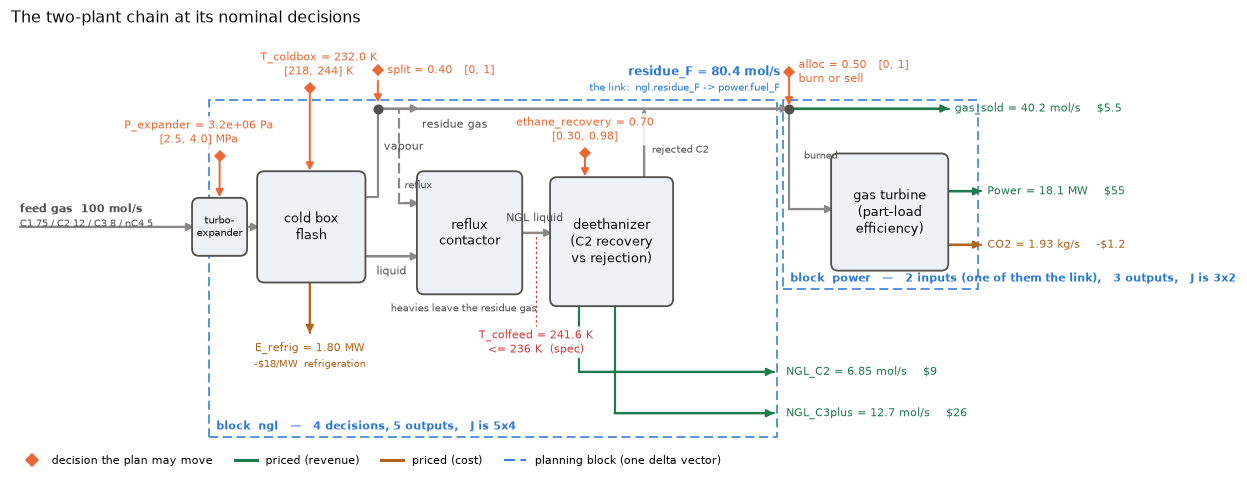

In [2]:
problem = chain_mod.two_plant_chain()
net = problem.network
state = net.evaluate(net.decision_start())          # the nominal operating point

ax = draw_chain(state.as_dict(), prices=problem.prices, specs=problem.specs,
                title="The two-plant chain at its nominal decisions")

Everything the plan is about is in that picture:

* **orange diamonds** are the five decisions — the only quantities the planner may set.
  Everything else on the diagram is a consequence of them, computed by the blocks.
* **green and brown streams** carry a price; price times flow, summed over them,
  *is* the objective.
* `residue_F` is the **link**, drawn in blue: an output of `ngl` and, unchanged, the inlet
  of `power`.
* `T_colfeed`, the deethanizer feed temperature, carries the one **spec**: it must not
  exceed 236 K. It is not priced — it only limits.
* the dashed boxes are the two **planning blocks**. Each is linearised into one delta
  vector, and each may contain as much flowsheet as it likes: the flash's inner root find
  is inside the `ngl` box, not exposed to the LP.

In [3]:
print(net)
print("evaluation order  :", net.order)
print("free decisions    :", net.decision_names)
print("linked inlet      :", [l.target for l in net.links])
print("specs             :", problem.specs)

Network(blocks=['ngl', 'power'], links=1, n_decisions=5)
evaluation order  : ['ngl', 'power']
free decisions    : ['ngl.ethane_recovery', 'ngl.T_coldbox', 'ngl.split', 'ngl.P_expander', 'power.alloc']
linked inlet      : ['power.fuel_F']
specs             : [Spec(ngl.T_colfeed <= 236)]


In [4]:
values = state.as_dict()
rows = [(name, f"{values[name]:,.4g}", chain_mod.UNITS[name.split(".", 1)[1]],
         "decision" if name in net.decision_names else
         "link" if net.is_linked(name) else "computed")
        for name in net.input_names + net.output_names]
table(rows, ["variable", "value", "unit", "role"])

| variable            | value   | unit   | role     |
|---------------------|---------|--------|----------|
| ngl.ethane_recovery | 0.7     | -      | decision |
| ngl.T_coldbox       | 232     | K      | decision |
| ngl.split           | 0.4     | -      | decision |
| ngl.P_expander      | 3.2e+06 | Pa     | decision |
| power.fuel_F        | 80.44   | mol/s  | link     |
| power.alloc         | 0.5     | -      | decision |
| ngl.NGL_C2          | 6.852   | mol/s  | computed |
| ngl.NGL_C3plus      | 12.71   | mol/s  | computed |
| ngl.residue_F       | 80.44   | mol/s  | computed |
| ngl.E_refrig        | 1.799   | MW     | computed |
| ngl.T_colfeed       | 241.6   | K      | computed |
| power.Power         | 18.06   | MW     | computed |
| power.CO2           | 1.93    | kg/s   | computed |
| power.gas_sold      | 40.22   | mol/s  | computed |

## 2. What is being planned

Three questions come before any result, and the planner can answer all three from the model
it is about to solve, so that the statement cannot drift away from the code.

**What are we planning?** A profit rate, in \$/h: every priced stream times its price.
Products and power earn, refrigeration and CO₂ cost. Prices are *linear in the block
outputs*, which is exactly what keeps the model an LP.

**What may be changed to get it?** Five decisions, each with physical bounds. Nothing else:
the residue flow, the products, the duties and the column feed temperature are all
*consequences*, and the LP is not free to pick them.

**What may not be violated?** The decision bounds, the link, the one temperature spec — and,
less obviously but more importantly, the models themselves: a proposal is only worth
anything if the real blocks agree with it, which is what the trust region in section 6 is
for.

In [5]:
planner = problem.planner(radius=0.25)
print(planner.describe())

Planning problem: maximise the priced objective

    9 ngl.NGL_C2 + 26 ngl.NGL_C3plus - 18 ngl.E_refrig + 55 power.Power + 5.5
    power.gas_sold - 1.2 power.CO2

  by choosing 5 decisions (a trust region lets each move 0.25 of its bound range per cycle):
    ngl.ethane_recovery        start        0.7   in [0.3, 0.98]          step +/- 0.17
    ngl.T_coldbox              start        232   in [218, 244]           step +/- 6.5
    ngl.split                  start        0.4   in [0, 1]               step +/- 0.25
    ngl.P_expander             start    3.2e+06   in [2.5e+06, 4e+06]     step +/- 3.75e+05
    power.alloc                start        0.5   in [0, 1]               step +/- 0.25

  everything else follows from the blocks (8 outputs, 1 link):
    power.fuel_F               = ngl.residue_F   (not a free decision)
    not priced: ngl.T_colfeed (constrained)

  subject to:
    T_colfeed        ngl.T_colfeed <= 236   (elastic, 10000 per unit of violation)
    the decision bounds 

The same chain, with the units stripped away and only what the LP holds left behind:

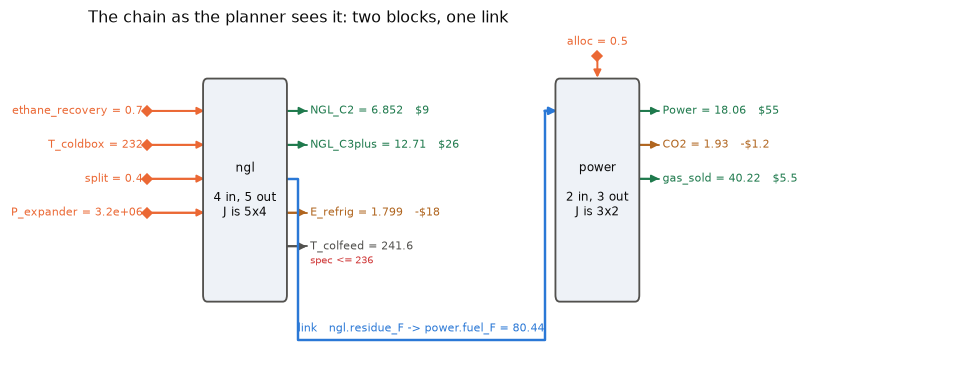

In [6]:
ax = draw_planning_network(net, prices=problem.prices, specs=problem.specs,
                           values=values,
                           title="The chain as the planner sees it: two blocks, one link")

Read it as the LP does. Each block contributes one matrix $J$ and a base point; the link is
a single equality row; the priced outputs are the objective; the spec is one inequality
row. Nothing about a flash, a reflux ratio or a turbine efficiency curve survives into the
LP — that is the whole point of a delta-base model, and it is also why the delta vectors
have to be honest.

## 3. The delta vectors

A delta vector is one AD pass per block: $J_{ij} = \partial y_i / \partial u_j$ at the
current operating point, taken *through* the flash's root find rather than around it.

Two things are worth checking before trusting one.

**Does it agree with the perturbation it replaces?** `check_delta_vectors` runs central
differences — the $2n$-evaluation method a commercial planner uses — and compares.

In [7]:
ngl = chain_mod.ngl_block()
check = check_delta_vectors(ngl, rtol=1e-4)
print(f"AD mode                : {check['mode']}")
print(f"max relative error     : {check['max_rel_error']:.3e}")
print(f"passes at rtol = 1e-4  : {check['passed']}")

AD mode                : fwd
max relative error     : 8.230e-11
passes at rtol = 1e-4  : True


**Which AD mode?** Reverse mode builds the Jacobian one *output* at a time and forward mode
one *input* at a time, so the cheaper mode is the one with fewer of them. The planner picks
by shape rather than hard-coding either.

In [8]:
print("80 decisions, scalar objective :", choose_ad_mode(n_u=80, n_y=1))
print("1 lever, 40 reported outputs   :", choose_ad_mode(n_u=1,  n_y=40))
print("the NGL block (4 in, 5 out)    :", linearize_block(ngl).mode)

80 decisions, scalar objective : rev
1 lever, 40 reported outputs   : fwd
the NGL block (4 in, 5 out)    : fwd


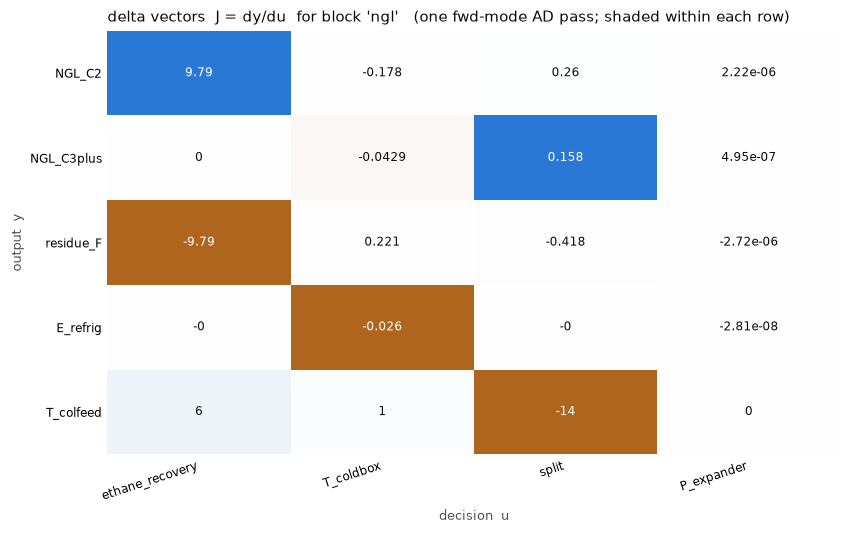

In [9]:
lin = linearize_block(ngl)
ax = draw_delta_vectors(lin, block=ngl)

Read the first column: raising ethane recovery by one unit adds 9.8 mol/s of ethane product
and takes 9.8 mol/s straight out of the residue gas. That trade is the whole plan, and the
LP will find it whatever the prices are.

Each row is shaded against its own largest entry, because the rows carry different units: a
colour scale shared between mol/s and K would be a picture of the unit system, not of the
model. The last column looks empty and is not: `P_expander` is in pascals, so
$2.2\times10^{-6}$ mol/s per Pa is 3.3 mol/s of ethane across its 1.5 MPa range. Scaled by
their own bound ranges, the four entries of the `NGL_C2` row are 6.7, 4.6, 0.3 and 3.3
mol/s — and the one that barely matters is `split`, which looks perfectly respectable in
raw units. Raw Jacobian entries carry whatever units they were asked for; scale by the
bound range before ranking levers, which is what `vertex_seeds` does internally.

### A delta vector is a *model*, and it is only local

The LP never sees the block. It sees the straight line through the base point, and it will
happily walk to the end of that line if the price says so. Here is the line against the
block it stands for:

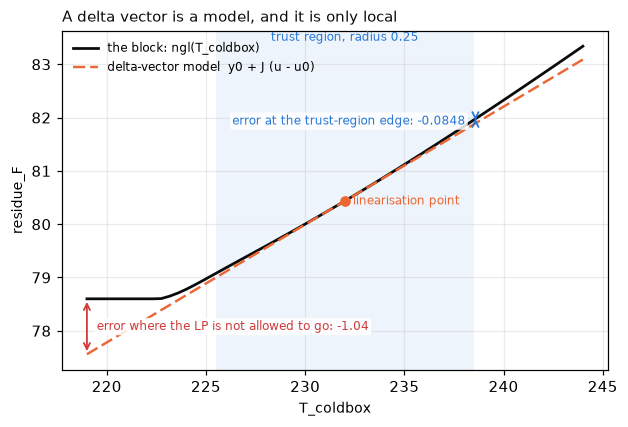

In [10]:
ax = draw_taylor_model(ngl, "T_coldbox", "residue_F", radius=0.25)

Inside the shaded band the two are indistinguishable — that band is one trust-region step,
and the model is doing its job there. Outside it, on the left, the cold box has run into a
regime the tangent knows nothing about and the prediction is off by a whole mol/s.

That is the entire argument for a trust region: not that the delta vector is inaccurate,
but that its accuracy is *local*, and the LP has no way to know where it stops.

## 4. What the derivatives cost

Two derivatives are in play here, and they scale differently.

* A **delta vector** is a block Jacobian. AD builds it in $\min(n_u, n_y)$ passes; central
  differences need $2n_u$ evaluations. For the NGL block that is 4 forward-mode JVPs against
  8 evaluations — a constant factor, plus exactness through the flash. A horizon replicates
  the blocks per period rather than enlarging them, so this per-block cost does not grow
  with the size of the plan.
* The **gradient of a scalar** — the planner's objective, a merit function, a spec — is one
  reverse-mode pass whatever $n$ is, where perturbation still needs $2n$ evaluations. That
  is the asymptotic argument, and it is what is measured below.

A planning horizon is how $n$ gets large: each period adds five decisions, so $n = 5H$. The
table times the reverse-mode gradient of the planner objective against central differences
on the same function.

In [11]:
def make_problem(n):
    prob = chain_mod.two_plant_chain(horizon=n // 5)
    return planner_objective(prob.planner()), prob.network.decision_start()

rows = scaling_study(make_problem, [5, 10, 20, 40, 80], repeats=3, mode="rev")
display(Markdown(format_scaling_table(rows)))

|   n |   one eval |   AD gradient |   FD gradient |   AD / eval |   FD / eval |   speedup |
|-----|------------|---------------|---------------|-------------|-------------|-----------|
|   5 | 3.95e-06 s |    5.87e-06 s |    0.000745 s |        1.5x |        189x |      127x |
|  10 | 4.74e-06 s |    8.46e-06 s |     0.00166 s |        1.8x |        349x |      196x |
|  20 | 8.68e-06 s |     1.4e-05 s |     0.00348 s |        1.6x |        401x |      249x |
|  40 | 1.83e-05 s |    2.44e-05 s |     0.00648 s |        1.3x |        353x |      266x |
|  80 | 5.06e-05 s |    0.000104 s |        0.02 s |        2.1x |        396x |      193x |

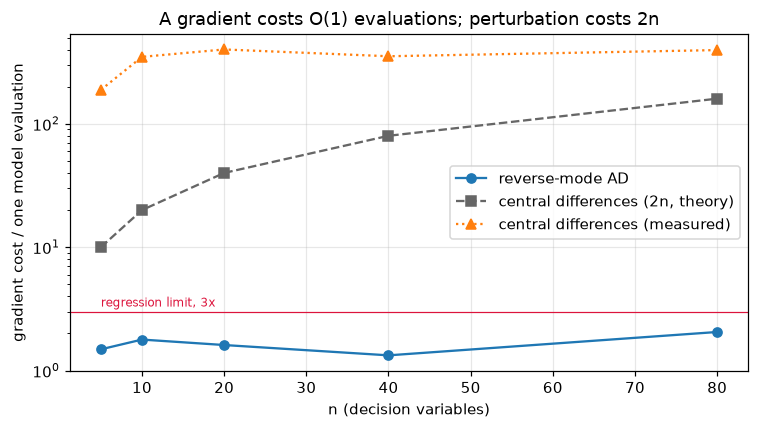

In [12]:
ns = [r.n for r in rows]
fig, ax = plt.subplots()
ax.plot(ns, [r.ad_ratio for r in rows], "o-", label="reverse-mode AD")
ax.plot(ns, [2 * n for n in ns], "s--", color="0.4", label="central differences (2n, theory)")
ax.plot(ns, [r.fd_ratio for r in rows], "^:", label="central differences (measured)")
ax.set(xlabel="n (decision variables)", ylabel="gradient cost / one model evaluation",
       yscale="log", title="A gradient costs O(1) evaluations; perturbation costs 2n")
ax.axhline(3.0, color="crimson", lw=0.8)
ax.text(ns[0], 3.3, "regression limit, 3x", color="crimson", fontsize=8)
ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()

The AD gradient stays a small constant multiple of one evaluation across the whole sweep,
with no trend in $n$. On some runs it even dips *below* one: on a compiled model XLA prunes parts of the
forward program the gradient does not need, so the two are not strictly nested. The measured
finite-difference cost runs *above* the $2n$ line because each of the $2n$ calls also pays
Python dispatch on a sub-millisecond model; on a slower rigorous simulator the two lines
converge. Either way the gap grows linearly, and planning is where $n$ grows.

## 5. The linear program that gets solved

Collect the block inputs and outputs of every block into one vector $x$, and add one slack
$s_k \ge 0$ for each elastic spec. For blocks $b$, links $(s \to t)$ and specs $k$, the
subproblem solved in each trust-region cycle is

$$
\begin{aligned}
\max_{x,\;s}\quad
  & \sum_{v} c_v\, x_v \;-\; \sum_k \pi_k\, s_k
  && \text{priced outputs, less a charge for slack} \\[2pt]
\text{s.t.}\quad
  & y_b - J_b\,u_b \;=\; y_b^{0} - J_b\,u_b^{0}
  && \text{model rows: the delta vectors} \\[2pt]
  & u_t - y_s \;=\; 0
  && \text{link rows: the network} \\[2pt]
  & a_k^{\top} x - s_k \;\le\; r_k
  && \text{spec rows} \\[2pt]
  & \max\!\left(l_i,\; u_i^{0} - \Delta_i\right) \;\le\; u_i \;\le\;
    \min\!\left(h_i,\; u_i^{0} + \Delta_i\right)
  && \text{bounds}\;\cap\;\text{trust region} \\[2pt]
  & s_k \ge 0, \qquad \Delta_i = r\,(h_i - l_i)
\end{aligned}
$$

Line by line:

* the **objective** is linear because prices multiply *outputs*, never products of
  variables. A stream quality times a stream flow would be bilinear, and no amount of good
  linearisation makes a bilinear program convex — that is the pooling problem, and it is
  out of scope (section 12).
* the **model rows** are the delta vectors, one row per block output. They are the only
  place the flowsheet enters. $y^0_b - J_b u^0_b$ is the "base" of base-plus-delta.
* the **link rows** are the flowsheet's connectivity. Eliminating them reproduces the chain
  rule, which is why linearising blocks separately and letting the LP couple them is
  equivalent, at first order, to differentiating the composed chain — while keeping each
  $J_b$ as a separate, inspectable, auditable artefact.
* the **spec rows** are elastic: the slack $s_k$ lets the LP stay feasible and report *how*
  it would have to violate a spec, rather than returning "infeasible" and nothing else. The
  penalty $\pi_k$ makes slack expensive. Section 6 covers why the realised violation is
  then re-scored against the nonlinear blocks.
* the **bounds** carry both the physical limits and the trust region, intersected. This is
  where the trust-region radius $r$ — the `radius` argument — actually acts; it is a
  fraction of each decision's own bound range, so one number covers decisions in kelvin and
  decisions in pascals.

And here is that program, for this chain, at the nominal point:

In [13]:
lp = planner.build_lp(planner.linearize(state), state, radius=0.25)
print(lp.as_text())

maximise  (written below as the minimisation actually solved)
  min  - 9 ngl.NGL_C2 - 26 ngl.NGL_C3plus + 18 ngl.E_refrig - 55 power.Power + 1.2 power.CO2 - 5.5 power.gas_sold + 1e+04 slack[T_colfeed]
subject to
  model[ngl.NGL_C2]                  ngl.NGL_C2 - 9.788 ngl.ethane_recovery + 0.1783 ngl.T_coldbox - 0.2603 ngl.split - 2.223e-06 ngl.P_expander == 34.14
  model[ngl.NGL_C3plus]              ngl.NGL_C3plus + 0.0429 ngl.T_coldbox - 0.1578 ngl.split - 4.947e-07 ngl.P_expander == 21.02
  model[ngl.residue_F]               ngl.residue_F + 9.788 ngl.ethane_recovery - 0.2212 ngl.T_coldbox + 0.4181 ngl.split + 2.718e-06 ngl.P_expander == 44.84
  model[ngl.E_refrig]                ngl.E_refrig + 0.026 ngl.T_coldbox + 2.812e-08 ngl.P_expander == 7.921
  model[ngl.T_colfeed]               ngl.T_colfeed - 6 ngl.ethane_recovery - ngl.T_coldbox + 14 ngl.split == 11
  model[power.Power]                 power.Power - 0.2469 power.fuel_F - 39.71 power.alloc == -21.66
  model[power.CO2]        

Fifteen columns and ten rows for a two-plant chain — five decisions, eight outputs, one
linked inlet and one slack. A horizon of 12 periods is twelve copies of this: the chain
replicates its blocks per period, and a cross-period constraint such as a CO₂ cap
(`two_plant_chain(co2_cap=...)`) adds one more inequality row over all of them. It is still
an LP.

Two things in the printout are worth pausing on. The bounds on `ngl.T_coldbox` read
`[225.5, 238.5]`, not the physical `[218, 244]`: that is the trust region biting — a quarter
of the 26 K bound range either side of the base point, so 232 ± 6.5 K. And
`slack[T_colfeed]` is priced at 10 000 — high enough that the LP will not casually buy its
way out of the spec, low enough that it always has an answer rather than reporting
"infeasible" and nothing else.

## 6. The trust region, and why it has an acceptance test

Each cycle linearises, solves that LP, and then **evaluates the caller's own nonlinear
blocks at the proposal**, accepting only on realised improvement:

$$
\rho = \frac{\text{merit(proposal)} - \text{merit(incumbent)}}
            {\text{merit predicted by the LP} - \text{merit(incumbent)}}
$$

$\rho \approx 1$ means the LP told the truth; $\rho < 0$ means the model got *worse* where
the LP promised better. Steps are accepted when $\rho$ clears a threshold and the region
grows; otherwise the step is thrown away and the region shrinks. Without that test — the
"recursion" heuristic — repeated re-linearisation walks the iterate outside where any Taylor
model is valid.

The theory is Eason and Biegler (AIChE J 62(9), 2016, doi:10.1002/aic.15325). Their
first-order consistency requirement is met *exactly* by an AD Taylor model, not just to
truncation error, which is why this loop can claim convergence where "recursion" cannot.

Here is the loop on a block with a known optimum at $(0.3,\,0.7)$.

In [14]:
from difflow.planning import TrustRegionOptions

bowl = Block(name="q", fn=lambda u: jnp.array([-(u[0] - 0.3) ** 2 - (u[1] - 0.7) ** 2]),
             u_names=["x", "y"], y_names=["f"], lb=[0.0, 0.0], ub=[1.0, 1.0])
bowl_net = Network([bowl])

guarded = DeltaBasePlanner(bowl_net, prices={"q.f": 1.0}, radius=0.3).solve()
unguarded = DeltaBasePlanner(bowl_net, prices={"q.f": 1.0}, radius=0.3,
                             accept_test=False, vertex_seeding=False,
                             options=TrustRegionOptions(radius=0.3, max_iter=40)).solve()

print(f"with acceptance test : converged={guarded.converged}  "
      f"plan={np.round(guarded.decisions, 6)}")
print(f"without              : converged={unguarded.converged}  "
      f"plan={np.round(unguarded.decisions, 6)}")
print(f"\nrho on the first six unguarded steps: "
      f"{[round(h.rho, 3) for h in unguarded.history[:6]]}")
print("(rho < 0 means the nonlinear model got *worse* where the LP promised better)")

with acceptance test : converged=True  plan=[0.3 0.7]
without              : converged=False  plan=[0.5 0.5]

rho on the first six unguarded steps: [0.25, -0.5, 0.25, -0.5, 0.25, -0.5]
(rho < 0 means the nonlinear model got *worse* where the LP promised better)


Vertex seeding hands the guarded run the right corner immediately, which is the point of it
but not much of a picture. Switch it off and watch the loop walk there from the middle:

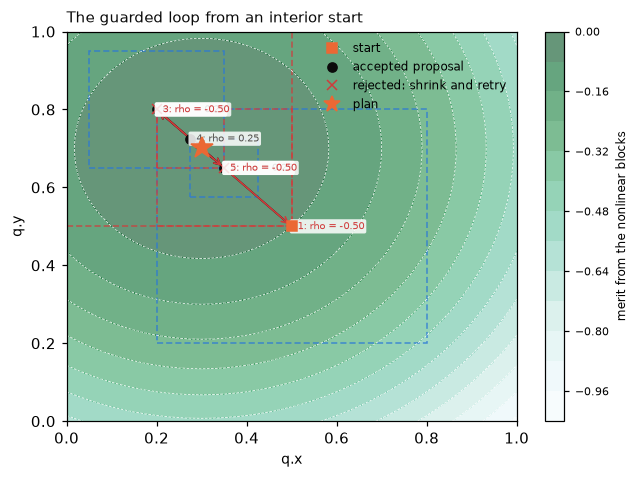

In [15]:
walk = DeltaBasePlanner(bowl_net, prices={"q.f": 1.0}, radius=0.3,
                        vertex_seeding=False).solve()
ax = draw_trust_region(walk, grid=41, max_cycles=6,
                       title="The guarded loop from an interior start")

A linear objective always sends the LP to a corner of its box, so the first proposal is
$(0.2,\,0.8)$ — past the optimum, but the block confirms an improvement ($\rho = 0.25$) and
the step is taken. Re-linearised there, the next LP points back the other way and proposes
the opposite corner; the block is *worse* there, $\rho = -0.5$, so the step is thrown away
and the box halves. From then on the loop brackets $(0.3,\,0.7)$, halving the region each
time it overshoots. The tail is dozens of ever-smaller boxes on top of the solution, so only
the first six cycles are drawn.

A second trap sits next to this one. Elastic slacks keep the LP feasible, but if realised
economics are scored on the LP's *own* prediction, a planner with stale coefficients scores
well precisely by running off-spec. `planner.score` therefore always evaluates the nonlinear
blocks — we come back to it with a real plan in hand in the next section.

## 7. The plan

With the problem stated and the loop understood, solve it.

In [16]:
warnings.simplefilter("ignore", PhaseBoundaryWarning)   # section 9 looks at these

result = planner.solve()
print(result.summary())

Plan (converged, stationary, 3 iterations, 9 start(s))
  objective             2470.47
  merit                 2470.47   (objective less realised-violation charge)
  violation                   0   (from the nonlinear model, not the LP)
  final radius              0.5
  decisions:
    ngl.ethane_recovery                         0.3
    ngl.T_coldbox                             237.2
    ngl.split                                     1
    ngl.P_expander                          2.5e+06
    power.alloc                                   1


**What had to change to get it?** Against the nominal start:

In [17]:
lb, ub = (np.asarray(a) for a in net.decision_bounds())
start = np.asarray(net.decision_start())


def corner(value, lo, hi, tol=1e-6):
    span = max(hi - lo, 1.0)
    if abs(value - lo) < tol * span:
        return "at its LOWER bound"
    if abs(value - hi) < tol * span:
        return "at its UPPER bound"
    return "interior"


rows = [(name, chain_mod.UNITS[name.split(".", 1)[1]], f"{start[i]:,.4g}",
         f"{result.decisions[i]:,.4g}", f"{result.decisions[i] - start[i]:+,.4g}",
         corner(result.decisions[i], lb[i], ub[i]))
        for i, name in enumerate(net.decision_names)]
table(rows, ["decision", "unit", "start", "plan", "change", "where it ended"])

| decision            | unit   | start   | plan    | change   | where it ended     |
|---------------------|--------|---------|---------|----------|--------------------|
| ngl.ethane_recovery | -      | 0.7     | 0.3     | -0.4     | at its LOWER bound |
| ngl.T_coldbox       | K      | 232     | 237.2   | +5.2     | interior           |
| ngl.split           | -      | 0.4     | 1       | +0.6     | at its UPPER bound |
| ngl.P_expander      | Pa     | 3.2e+06 | 2.5e+06 | -7e+05   | at its LOWER bound |
| power.alloc         | -      | 0.5     | 1       | +0.5     | at its UPPER bound |

**And what does that buy?** The objective, term by term — this table *is* the objective row
of the LP, evaluated on the nonlinear blocks at the plan:

In [18]:
rows = []
for var, price in planner.prices.items():
    amount = result.values[var]
    rows.append((var, chain_mod.UNITS[var.split(".", 1)[1]], f"{amount:,.4g}",
                 f"{price:+g}", f"{price * amount:+,.1f}"))
rows.append(("total", "", "", "", f"{result.objective:+,.1f}"))
table(rows, ["priced variable", "unit", "amount", "price ($)", "$/h"])

| priced variable   | unit   | amount   | price ($)   | $/h      |
|-------------------|--------|----------|-------------|----------|
| ngl.NGL_C2        | mol/s  | 2.011    | +9          | +18.1    |
| ngl.NGL_C3plus    | mol/s  | 12.19    | +26         | +317.0   |
| ngl.E_refrig      | MW     | 1.686    | -18         | -30.3    |
| power.Power       | MW     | 39.47    | +55         | +2,170.6 |
| power.gas_sold    | mol/s  | 0        | +5.5        | +0.0     |
| power.CO2         | kg/s   | 4.118    | -1.2        | -4.9     |
| total             |        |          |             | +2,470.5 |

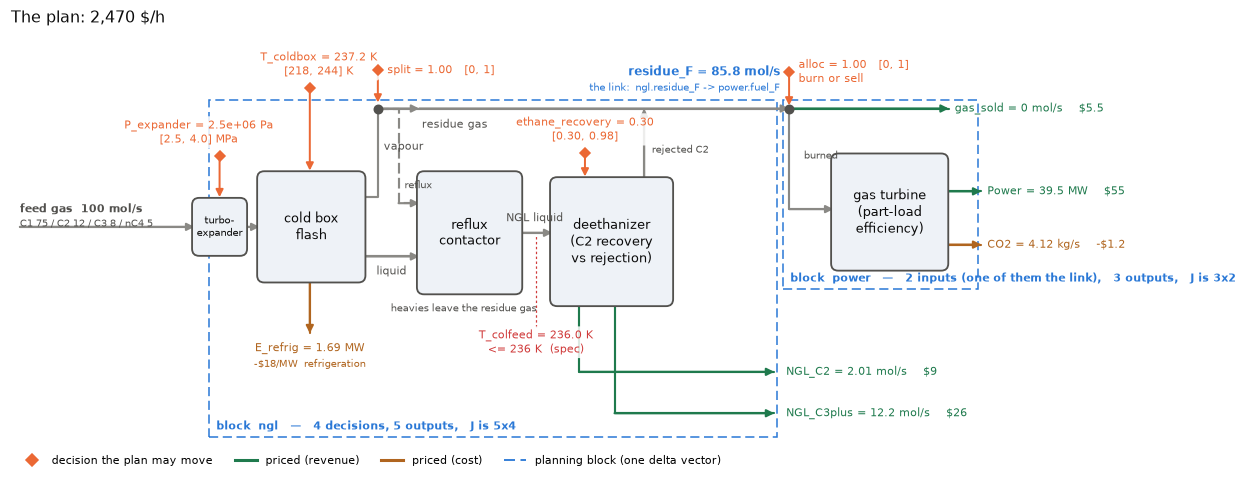

In [19]:
ax = draw_chain(result.values, prices=problem.prices, specs=problem.specs,
                title=f"The plan: {result.objective:,.0f} $/h")

`alloc = 1` and `ethane_recovery` at its *lower* bound: at a power price of \$55/MW the
residue gas is worth more burned than sold, and ethane is worth more rejected into that
residue than recovered as product. Both levers are at a bound — they are bang-bang, and the
price sweep below shows them switching rather than sliding.

Four of the five decisions end at a bound, which is what an LP does. The exception is
`T_coldbox`, and the reason is the spec: refrigeration costs \$18/MW, so the plan wants the
cold box as warm as it can have it, and 236 K on the deethanizer feed is exactly how warm
that is. The constraint, not the price, sets that lever.

Before reading any of that as money, check it against the real blocks rather than the LP's
own prediction:

In [20]:
scored = planner.score(result.decisions)
print(f"objective from the real blocks : {scored['objective']:.2f}")
print(f"realised violations            : {scored['violations']}")
print(f"merit (objective less charge)  : {scored['merit']:.2f}")
print(f"T_colfeed = {result.values['ngl.T_colfeed']:.2f} K   (spec <= 236 K)")

objective from the real blocks : 2470.47
realised violations            : {'T_colfeed': 0.0}
merit (objective less charge)  : 2470.47
T_colfeed = 236.00 K   (spec <= 236 K)


### A lever that switches

Bang-bang levers do not slide with price, they *switch*. Sweep the power price and watch.

In [21]:
power_prices = np.linspace(5.0, 60.0, 12)
sweep = []
for price in power_prices:
    p = problem.planner(radius=0.25)
    p.prices = dict(problem.prices)
    p.prices["power.Power"] = float(price)
    r = p.solve()
    sweep.append((r.plan["power.alloc"], r.plan["ngl.ethane_recovery"], r.objective))

alloc, recovery, profit = map(np.array, zip(*sweep))

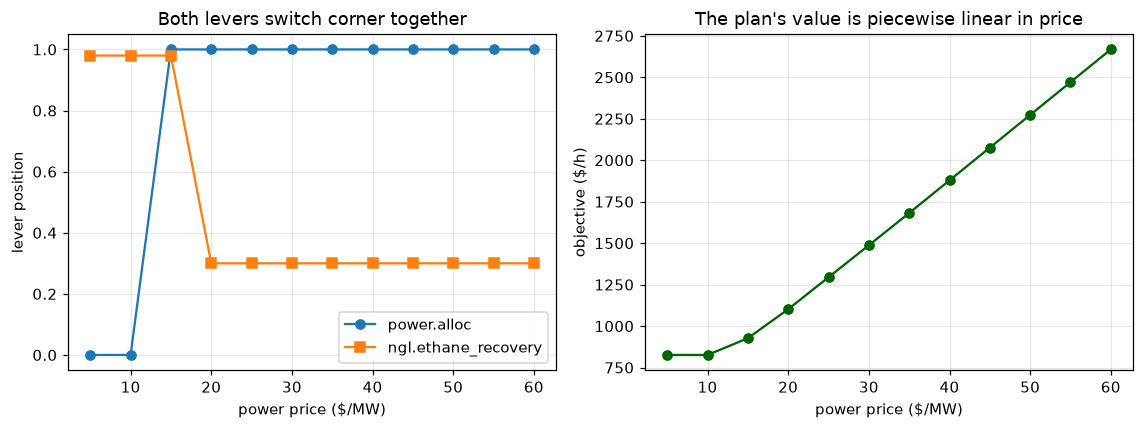

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.0))
ax1.plot(power_prices, alloc, "o-", label="power.alloc")
ax1.plot(power_prices, recovery, "s-", label="ngl.ethane_recovery")
ax1.set(xlabel="power price ($/MW)", ylabel="lever position",
        title="Both levers switch corner together")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(power_prices, profit, "o-", color="darkgreen")
ax2.set(xlabel="power price ($/MW)", ylabel="objective ($/h)",
        title="The plan's value is piecewise linear in price")
ax2.grid(alpha=0.3)
fig.tight_layout()

A single interior start would decide that corner by whichever way the local slope happened to
point. The planner also seeds from bound vertices of the most price-sensitive decisions —
ranked with one reverse-mode AD pass, whatever $n$ is.

In [23]:
seeds = planner.vertex_seeds()
print(f"{len(seeds)} vertex seeds, on top of the nominal start")
print("decision names:", net.decision_names)
for s in seeds[:4]:
    print("  ", np.array2string(s, precision=4, suppress_small=True))
print(f"\nthe winning run used {result.n_starts} starts in total")

8 vertex seeds, on top of the nominal start
decision names: ['ngl.ethane_recovery', 'ngl.T_coldbox', 'ngl.split', 'ngl.P_expander', 'power.alloc']
   [      0.3     218.        0.4 3200000.        0. ]
   [      0.3     244.        0.4 3200000.        0. ]
   [      0.98     218.         0.4  3200000.         0.  ]
   [      0.98     244.         0.4  3200000.         0.  ]

the winning run used 9 starts in total


The useful question about a bang-bang lever is not its derivative — which is zero — but
where it flips. `price_switch_point` bisects for it.

In [24]:
switch = price_switch_point(problem.planner(radius=0.25), "power.Power", 5.0, 60.0,
                            decision="power.alloc", tol=0.05)
print(f"power.alloc switches at a power price of ${switch['price']:.2f}/MW")
print(f"  below: alloc = {switch['plan_low']['power.alloc']:.3f}"
      f"   above: alloc = {switch['plan_high']['power.alloc']:.3f}")

power.alloc switches at a power price of $12.08/MW
  below: alloc = 0.000   above: alloc = 1.000


## 8. The sensitivity of the plan, not just the plan

Because the blocks are differentiable, the converged plan can itself be differentiated:
$\mathrm{d}(\text{plan})/\mathrm{d}(\text{price})$,
$\mathrm{d}(\text{profit}^*)/\mathrm{d}(\text{parameter})$. This is what k_aug and sIPOPT
give for a single NLP, obtained here by the implicit function theorem on the KKT conditions
at the plan. A planning system whose submodels are not differentiable structurally cannot
provide it.

Start with the chain at a power price of \$30/MW — above the \$12.08 switch found in
section 7, so the allocation lever has already flipped to burning.

In [25]:
mid = problem.planner(radius=0.25)
mid.prices = dict(problem.prices)
mid.prices["power.Power"] = 30.0
mid_result = mid.solve()
sens = mid_result.plan_sensitivity(wrt="prices")
print(sens.summary())

Plan sensitivity w.r.t. prices
  at a bound (d(plan)/d(param) = 0): ngl.ethane_recovery, ngl.split, ngl.P_expander, power.alloc
  active constraints: T_colfeed
  d(objective)/d(param):
    ngl.NGL_C2                              3.28583
    ngl.NGL_C3plus                          12.9024
    ngl.E_refrig                             1.6434
    power.Power                             38.5534
    power.gas_sold                                0
    power.CO2                               4.02296


Every row of $\mathrm{d}(\text{plan})/\mathrm{d}(\text{price})$ is zero, and that is the correct
answer rather than a failure. Four levers sit at a bound. The fifth, `T_coldbox`, is off its
bounds but not free: the active `T_colfeed` spec fixes it — one decision against one active
constraint, which leaves no degree of freedom for a price to move. This plan is a vertex, and
a vertex does not slide under an infinitesimal price change; it switches at a finite one,
which is what `price_switch_point` is for. The summary names the pinned levers rather than
letting a vertex be read as an interior solution.

Two things are still exact and useful at a vertex. The objective row is the envelope theorem:
$\mathrm{d}(\text{profit}^*)/\mathrm{d}c_k$ is the activity level of the thing priced at $c_k$.
And the multiplier on the active spec is its shadow price — what one more kelvin of
`T_colfeed` is worth — which a re-solve with the spec relaxed by 1 K confirms, to within
the curvature of a finite step:

In [26]:
shadow = abs(sens.multipliers["T_colfeed"])
relaxed = chain_mod.two_plant_chain(colfeed_max=237.0).planner(radius=0.25)
relaxed.prices = dict(mid.prices)
gain = relaxed.solve().objective - mid_result.objective
print(f"multiplier on T_colfeed          : {shadow:.4f} $/h per K")
print(f"re-solved with the spec at 237 K : {gain:+.4f} $/h")

multiplier on T_colfeed          : 0.4835 $/h per K
re-solved with the spec at 237 K : +0.4769 $/h


**A plan with a free lever.** For $\mathrm{d}(\text{plan})/\mathrm{d}(\text{price})$ to be
nonzero, some decision has to be off its bounds with no spec pinning it: an interior optimum,
which needs curvature in the objective. The chain has none to offer — every lever in it is
bang-bang — so take one block that does. A cracking-severity lever $s$ is the textbook case:
olefin yield passes through a maximum as the furnace starts over-cracking, while firing duty
rises linearly,

$$
\text{olefins} = 100\,(0.8\,s - 0.4\,s^2), \qquad E_\text{fire} = 20\,s .
$$

With prices $c_P$ on olefins and $c_E < 0$ on firing, the optimum is
$s^* = 1 + c_E/(4 c_P)$, so the sensitivity can be checked by hand as well as by re-solving
the plan at perturbed prices.

In [27]:
def cracker(u):
    s = u[0]
    return jnp.array([100.0 * (0.8 * s - 0.4 * s ** 2), 20.0 * s])

furnace = Block(name="crk", fn=cracker, u_names=["severity"],
                y_names=["olefins", "E_fire"], lb=[0.0], ub=[1.0], u0=[0.5])
c_P, c_E = 10.0, -30.0
crk_prices = {"crk.olefins": c_P, "crk.E_fire": c_E}


def plan_severity(prices):
    res = DeltaBasePlanner(Network([furnace]), prices=prices, radius=0.25).solve()
    return res, res.plan["crk.severity"]


crk_result, s_star = plan_severity(crk_prices)
crk_sens = crk_result.plan_sensitivity(wrt="prices")
print(f"planned severity {s_star:.4f}   (analytic {1 + c_E / (4 * c_P):.4f})\n")
print(crk_sens.summary())

h = 0.1
rows = []
analytic = {"crk.olefins": -c_E / (4 * c_P ** 2), "crk.E_fire": 1 / (4 * c_P)}
for k in crk_prices:
    up, dn = dict(crk_prices), dict(crk_prices)
    up[k] += h
    dn[k] -= h
    fd = (plan_severity(up)[1] - plan_severity(dn)[1]) / (2 * h)
    rows.append([f"d severity / d price[{k}]", f"{crk_sens.as_dict()['crk.severity'][k]:.6f}",
                 f"{fd:.6f}", f"{analytic[k]:.6f}"])
table(rows, headers=["", "KKT sensitivity", "re-solved plans", "analytic"])

planned severity 0.2500   (analytic 0.2500)

Plan sensitivity w.r.t. prices
  d(objective)/d(param):
    crk.olefins                                17.5
    crk.E_fire                                    5
  d(plan)/d(param):
                                       crk.olefins    crk.E_fire
    crk.severity                             0.075         0.025


|                                   | KKT sensitivity   | re-solved plans   | analytic   |
|-----------------------------------|-------------------|-------------------|------------|
| d severity / d price[crk.olefins] | 0.075000          | 0.075008          | 0.075000   |
| d severity / d price[crk.E_fire]  | 0.025000          | 0.025001          | 0.025000   |

The KKT system gives the same numbers as re-solving the plan twice per price, without the
re-solves, and it would give them for every price at once on a plan with many free levers.

The same machinery works against **model or design parameters**, which is what makes capital
planning tractable without enumerating scenarios. Back on the chain, whose plan is still a
vertex, only the objective row moves: another J/mol of turbine output is worth something,
while the design flow enters only through a part-load penalty that is inactive above design
load, and is worth nothing.

In [28]:
theta_sens = mid_result.plan_sensitivity(wrt="theta",
                                         params=["power.F_design", "power.w_net"])
print(theta_sens.summary())

Plan sensitivity w.r.t. theta
  at a bound (d(plan)/d(param) = 0): ngl.ethane_recovery, ngl.split, ngl.P_expander, power.alloc
  active constraints: T_colfeed
  d(objective)/d(param):
    power.F_design                                0
    power.w_net                          0.00251435


## 9. Phase boundaries

A delta vector computed across phase appearance or disappearance is *meaningless*, not merely
inaccurate: the function is not differentiable there, and the Taylor model extrapolates a
branch that has ceased to exist. difflow's flash guards its single-phase branch with safe
inputs, so the numbers keep coming — which is exactly why the planner has to say something.
(That flat left-hand tail in the section 3 figure is this, seen from the outside.)

The NGL block reports the cold box's vapour fraction as a phase indicator. Linearise it as a
subcooled liquid and then let refrigeration cost pull the cold box warmer.

In [29]:
cold = chain_mod.ngl_block()
u_subcooled = jnp.array([0.7, 222.0, 0.4, 4.0e6])
print("V_frac at the linearisation point :",
      float(cold.evaluate_phases(u_subcooled)[0]))

warm = DeltaBasePlanner(Network([cold]), prices={"ngl.E_refrig": -18.0},
                        radius=0.5, vertex_seeding=False)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    warm_result = warm.solve(u0=u_subcooled)

for w in caught:
    if w.category is PhaseBoundaryWarning:
        print("\n" + str(w.message))
        break

V_frac at the linearisation point : 0.0



block 'ngl': indicator 'V_frac' crossed a phase boundary between the linearisation point and the proposal (0 -> 0.1851, regime 0 -> 1). The delta vectors either side describe different functions, so this linearisation is not valid at the proposal — shrink the trust region or re-centre inside one regime.


## 10. Large models: is there a danger of gradient collapse?

A reasonable worry about scaling this to a whole refinery: if the plan is built from
derivatives, and a large flowsheet composes hundreds of units, does the signal vanish the way
it does in an RNN backpropagating through hundreds of timesteps?

**No — but three other things do degrade with size, and they have different remedies.**
`check_delta_health` reports all three.

First, the non-problem. Compose enough units and the sensitivity of a downstream product to an
upstream lever becomes numerically tiny. That is almost always *physics*, not numerical loss:


In [30]:
from difflow.planning import check_delta_health

def deep_chain(n):
    """n first-order stages in series; each stage damps by 1/(1+k)."""
    def fn(u):
        c = 1.0
        for i in range(n):
            c = c / (1.0 + u[i])
        return jnp.array([c])
    return Block(name="deep", fn=fn, u_names=[f"k{i}" for i in range(n)],
                 y_names=["c"], lb=[0.5] * n, ub=[1.5] * n, u0=[1.0] * n)

rows = []
for n in (10, 50, 100, 200):
    lin = linearize_block(deep_chain(n))
    y0, g, k1 = float(lin.y0[0]), float(lin.J[0, 0]), float(lin.u0[0])
    rows.append([n, f"{y0:.3e}", f"{g:.3e}", f"{g * k1 / y0:.6f}",
                 f"{-k1 / (1 + k1):.6f}"])

table(rows, headers=["depth", "y0", "dy/dk_1", "dln y/dln k_1", "exact"])


| depth   | y0        | dy/dk_1    | dln y/dln k_1   | exact     |
|---------|-----------|------------|-----------------|-----------|
| 10      | 9.766e-04 | -4.883e-04 | -0.500000       | -0.500000 |
| 50      | 8.882e-16 | -4.441e-16 | -0.500000       | -0.500000 |
| 100     | 7.889e-31 | -3.944e-31 | -0.500000       | -0.500000 |
| 200     | 6.223e-61 | -3.112e-61 | -0.500000       | -0.500000 |

The outlet reaches `1e-61` and the *relative* sensitivity is still exact to every digit.
Nothing was lost — `y` itself is `1e-61`. The LSTM analogy breaks on three counts: difflow
enables `float64` at import (~300 orders of headroom, not `float32`'s 38), a flowsheet is tens
of units deep rather than thousands of timesteps, and the trust-region loop re-linearises every
cycle instead of accumulating a product over many gradient steps.

The block decomposition matters here too. Linearising a whole plant as *one* `Block` does form
the deep chain-rule product and its entries do collapse; keeping it as linked blocks does not,
because each block is linearised where the network puts it and composition lives in the link
equality rows. Measured on a chain of identical stages in mixed engineering units, `cond(A_eq)`
saturates near `9e2` out to depth 128 while the monolithic Jacobian falls to `2.6e-25`.

Now the three that *are* real. **Dead levers** are the one genuine analogue of lost
information — every `clip`, `minimum` and `where` on an active spec contributes an *exactly*
zero column, and the LP then never moves that lever. The companion `dead_output` finding says
the capped output itself is now a constant, so any price or spec on it is being applied to a
number that cannot move:

In [31]:
def blend(u):
    """Gasoline pool whose octane is capped by a product spec.

    Butane is a cheap octane/RVP blend component that reaches the pool but
    carries no cost, so once the octane cap binds it reaches *nothing*.
    """
    reformate, alkylate, butane = u
    pool = 0.3 * reformate + 0.7 * alkylate + 0.05 * butane
    cost = 0.010 * reformate + 0.014 * alkylate
    return jnp.array([jnp.clip(pool, 0.0, 87.0), cost])

pinned = Block(name="blend", fn=blend,
               u_names=["reformate", "alkylate", "butane"],
               y_names=["RON", "cost"],
               lb=[70.0, 70.0, 0.0], ub=[100.0, 100.0, 20.0],
               u0=[95.0, 95.0, 5.0])      # linearised past the octane cap
report = check_delta_health(pinned)
print(report.summary())
print("\ndead levers:", report.dead_levers())

delta-vector health: 2 findings (0 error, 2 warning)
  [warning] dead_lever: blend.butane: delta column is structurally zero (max scaled sensitivity 0.000e+00); the LP will never move this lever. The lever is interior, so the zero comes from a saturated expression downstream of it — a clip, minimum or where on an active spec — rather than from the bound. Re-centre inside the smooth region, or model the saturation explicitly with a piecewise block rather than letting the clip hide it.
  [warning] dead_output: blend.RON: delta row is structurally zero (max scaled sensitivity 0.000e+00); this output is a constant to the LP. If it carries a price or appears in a spec, the plan is being made against a number that cannot move.

dead levers: ['blend.butane']


**Amplification, not attenuation**, is the second — and it is the one to expect in a refinery.
A tear solve differentiated implicitly returns `(I - A)^-1`, so a recycle of loop gain `g`
multiplies sensitivities by `1/(1 - g)`. Recycle-to-extinction loops push `g` toward one:

In [32]:
import optimistix as optx

def loop(u):
    gain, feed = u[0], u[1]
    sol = optx.root_find(lambda x, args: x - (feed + gain * x),
                         optx.Newton(rtol=1e-10, atol=1e-12), jnp.asarray(1.0))
    return jnp.array([sol.value])

rows = []
for g in (0.5, 0.9, 0.99, 0.999):
    u = jnp.array([g, 1.0])
    rows.append([f"{g:.3f}", f"{float(loop(u)[0]):.4f}",
                 f"{float(jax.jacrev(loop)(u)[0, 1]):.4f}", f"{1 / (1 - g):.4f}"])
table(rows, headers=["loop gain g", "x*", "dx/dfeed", "1/(1 - g)"])

hot = Block(name="hcu", fn=loop, u_names=["recycle_gain", "feed"], y_names=["x"],
            lb=[0.0, 0.5], ub=[0.999, 2.0], u0=[0.99, 1.0])
print(check_delta_health(hot).summary())


| loop gain g   | x*        | dx/dfeed   | 1/(1 - g)   |
|---------------|-----------|------------|-------------|
| 0.500         | 2.0000    | 2.0000     | 2.0000      |
| 0.900         | 10.0000   | 10.0000    | 10.0000     |
| 0.990         | 100.0000  | 100.0000   | 100.0000    |
| 0.999         | 1000.0000 | 1000.0000  | 1000.0000   |

delta-vector health: 1 findings (0 error, 1 warning)
  [warning] amplifying: hcu.recycle_gain: a trust-region step of radius 0.3 is predicted to change 'x' by 30x its own value; a first-order model does not survive that. Where the block contains a recycle this is the signature of a loop gain near one — implicit differentiation of the tear returns (I - A)^-1 — and the remedy is a smaller radius. Otherwise the block is simply strongly nonlinear here; consider a piecewise model.


**Scale spread** is the third, and the most mundane: ppm against kbbl/d against \$/bbl in one
constraint matrix. `planner.check_health()` adds `check_lp_scaling` over the assembled program
to catch it. It is a *units* problem — nondimensionalise the levers before blaming the
gradients.

One tension worth knowing about when scaling up: `Network` rejects inter-block recycles and
tells you to merge the loop into a single block. A plant-wide recycle therefore pushes you
toward a bigger block — which is exactly the monolithic case where sensitivities *do* collapse.
The protection is real, but it is contingent on being able to keep blocks small.

See [docs/planning.md](../docs/planning.md#large-models-what-degrades-and-what-does-not) for the
full measurements.

## 11. Handing the program to Pyomo

difflow is not short of solvers: `difflow.eo_solver` solves a flowsheet's equations
simultaneously with Newton through optimistix, the units carry their own root finds and
integrators, and the LP above is solved here with HiGHS through `scipy.optimize.linprog`.
What `difflow.planning` deliberately does not own is a *mathematical programming* stack —
no branch-and-bound, no interior point, no modelling language. `to_pyomo()` emits the
assembled program instead, so the same columns, rows and bounds printed in section 5 can go
to CBC, Gurobi or CPLEX, or be embedded in an IDAES superstructure. The SOS2 sets from a
piecewise block come across natively.

The relationship to the equation-oriented solver is worth stating, because the two are
close cousins. Both assemble every unit's equations into one system rather than marching
unit by unit: `eo_solver` solves the *nonlinear* residuals $F(x) = 0$; the planning LP is
the *linearised, priced, bounded* version of the same assembly — the delta vectors are its
model rows and the links are its connectivity rows, with an objective and specs bolted on,
which a simulation does not have. An EO solve answers "what does the plant do at these
inputs?"; the LP answers "which inputs pay best?"; and the trust-region loop alternates
between the two, which is exactly why its acceptance test is an EO-style nonlinear
evaluation.

In [33]:
try:
    import pyomo.environ as pyo
    model = result.pyomo_model
    print(f"{type(model).__name__}: {len(list(model.x.keys()))} variables, "
          f"{len(model.eq)} equality rows, {len(model.ub)} inequality rows")
    print("\nfirst few columns:")
    for name in list(model.x.keys())[:6]:
        lo, hi = model.x[name].bounds
        print(f"  {name:<24s} bounds=({lo}, {hi})")
except ImportError:
    print("Pyomo is not installed; `pip install \"difflow[planning]\"` to emit models.")

ConcreteModel: 15 variables, 9 equality rows, 1 inequality rows

first few columns:
  ngl.ethane_recovery      bounds=(0.3, 0.6399999999999999)
  ngl.T_coldbox            bounds=(224.2, 244.0)
  ngl.split                bounds=(0.5, 1.0)
  ngl.P_expander           bounds=(2500000.0, 3250000.0)
  power.fuel_F             bounds=(0.0, 185.79605279623627)
  power.alloc              bounds=(0.5, 1.0)


## 12. Where the boundary is

Two things are deliberately out of scope, and it is worth being explicit about both.

**A commercial planning system.** Crude assay libraries, unit submodel libraries, empirical
blending correlations (octane, RVP, cloud point), scheduling, multi-site transport, reporting
and audit trails. Those are the real moat of a product like PIMS. They are not derivable from
a flowsheet, and pretending otherwise would make this module worse.

**Pooling and blending nonconvexity.** A stream quality multiplied by a stream flow is
bilinear, and bilinear terms stay nonconvex no matter how good the unit linearisation is
(Haverly, ACM SIGMAP Bulletin 25, 1978). That needs global optimisation, not better delta
vectors. Pricing here is linear in the block outputs, which is what keeps the problem an LP.

What *is* in scope, and what a non-differentiable planner cannot do: exact first-order
consistency for the trust region, the sensitivity of the plan itself, gradient-based modifier
adaptation (`run_modifier_adaptation`), and constraint back-off sized by propagated
coefficient covariance (`constraint_backoff`). See `docs/planning.md` for those.